In [2]:
from lagrange import *

# Piecewise interpolation (task c)

## Introduction & Visualization:

An alternative to finding a polyniomial of degree $n$ that interpolates the $n+1$ nodes is dividing the nodes into subsections, the number of such subsections we will denote by $K$ and number of nodes in each subsection with $n$ (not to be confused with our original $n$). A piecewise interpolation with `equidistant` nodes with $K = 3, n=2$ is plotted down below to give an intuitive understanding of how a piecewise interpolation works.

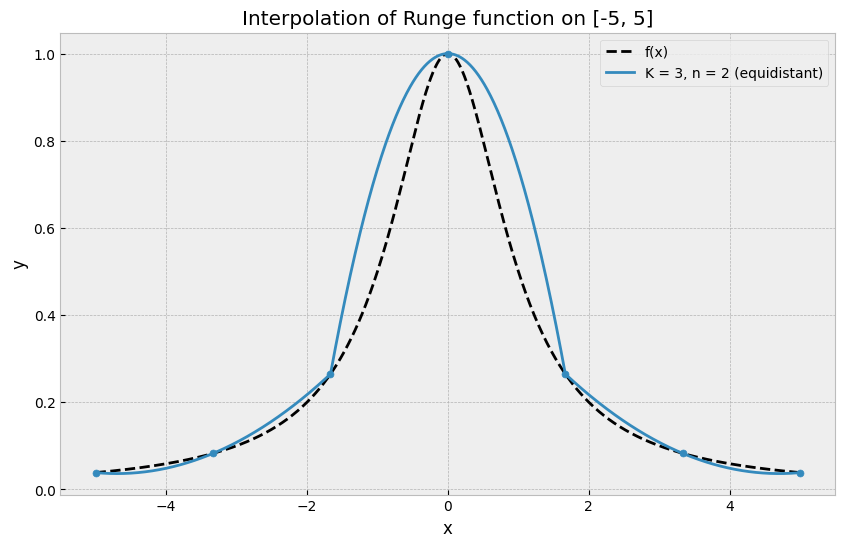

In [3]:
test = make_piecewise(runge, -5, 5, 3, 2)
plot_interpolant(-5,5,test)

## Error analysis:

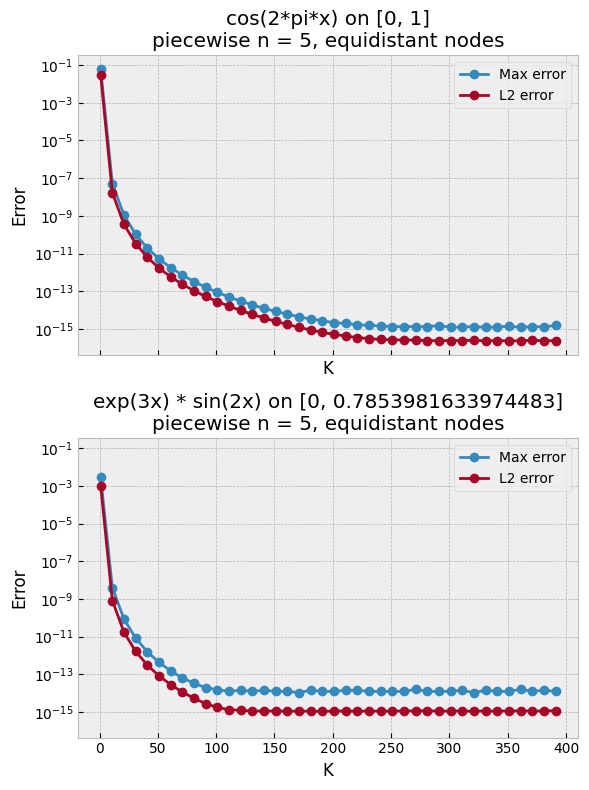

In [4]:
plot_piecewise_convergence([(f_cos, 0, 1),(f_expsin, 0, np.pi/4)], 1, 400,K_step = 10,nodes = ["equidistant"])

Above we have plotted the max-error of the piecewise interpolation with $n=5$ as a function of $K$, remember that convergence in max norm means convergce in the 2-norm. We see that the error converges to the same errors that regular interpolation with `Chebyshev` nodes did, strengthing the theory that this is just how close an interpolation can come before being limited by floating point errors.

The nodes that are interpolated over are equidistant, but we do not see the the same blow up that came when using regular interpolation. This suggests that this method is a more stable method compared to regular interpolation. And therefore more adventagous when we can not choose our interpolation nodes.

This method may be more stable, and converge to zero, but requires a larger amount of nodes. Remember that for $K$ subsections we need $Kn$ nodes. To get the same error as we got for $n=20$ `Chebyshev` nodes we require $K=100$, and therefore $400$ nodes. $20$ times the nodes to get the same error.

This suggests that piecewise interpolation is a surperior method in cases where we have access to a large amount of interpolation points without them necessarily being idealy placed.

## Runtime analysis:

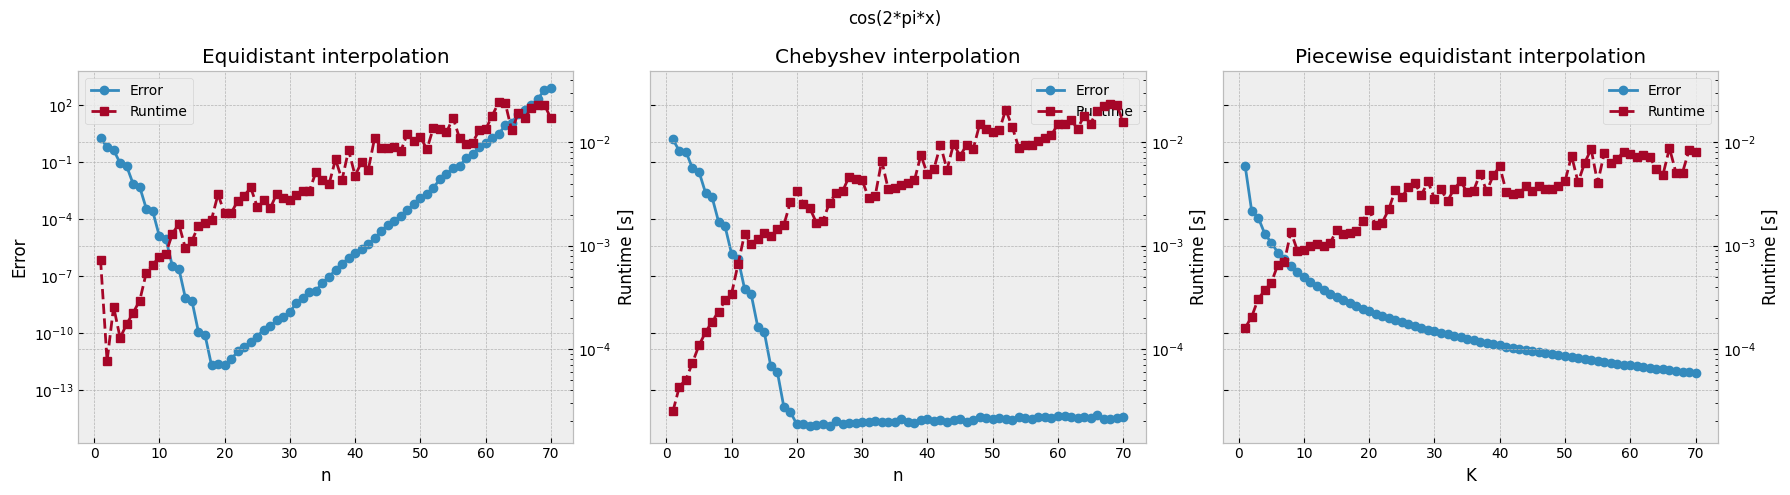

In [5]:
plot_time_interpolation(
    f_cos, 0, 1,
    n0=1, n_end=70,
    K0=1, K_end=70
)

Up intil now we have only looked at the error of our approximation, but runtime of interpolation is an important factor as well. Above we have plotted error and runtime for all the different interpolation methods we have looked at so far. The plots share a y-axis making it easy to compare. Important to note that piecewise interpolation is a function of $K$ while the others are functions of $n$. 

The obvious part is that the runtime of piecewise interpolation is faster than the other methods for the same number of nodes. For $n=50$ the regular interpolations have a runtime right under $10^{-2}$ seconds, while piecewise is right under $10^{-3}$ seconds (for $K=10$). A tenth of the runtime. This can be explained by use of $\mathcal{O}$-notation. To avoid confusion with notation we switch the $n$ in piecewise with $m$. Also note that $K = n/m$. For regular interpolation one loops over $n+1$ nodes, where for each iteration $n+1$ calculations are done. Making the runtime be $\mathcal{O}(n^2)$. Piecwise first finds the subsection that corresponds to the point, which takes $\mathcal{O}(K)$ time. Once the the section is found, $(m+1)^2$ calculations are done. Making the runtime be $\mathcal{O}(K+m^2) = \mathcal{O}(K) = \mathcal{O}(n)$. Suggesting that for a large amount of nodes piecewise is a better method to avoid high runtimes.

What if we want a fast interpolation that gives us a max-error of $10^{-10}$, what method is best? By reading of the plot we get approximate times:
- `Equidistant`: $10^{-3}$ s
- `Chebyshev`: $10^{-3.4}$ s
- `Piecewise`: $10^{-2.7}$ s

To achive the same precision as the regular interpolation piecewise needs a significantly longer runtime. But what if instead we are satisfied with a higher error of $10^{-4}$. Then the different methods have similiar runtime, suggesting that piecewise could be a better method when super precise interpolation is not needed. E.g. where other factors of error will make all interpolations with low enough error equal.


## Stability under noise:

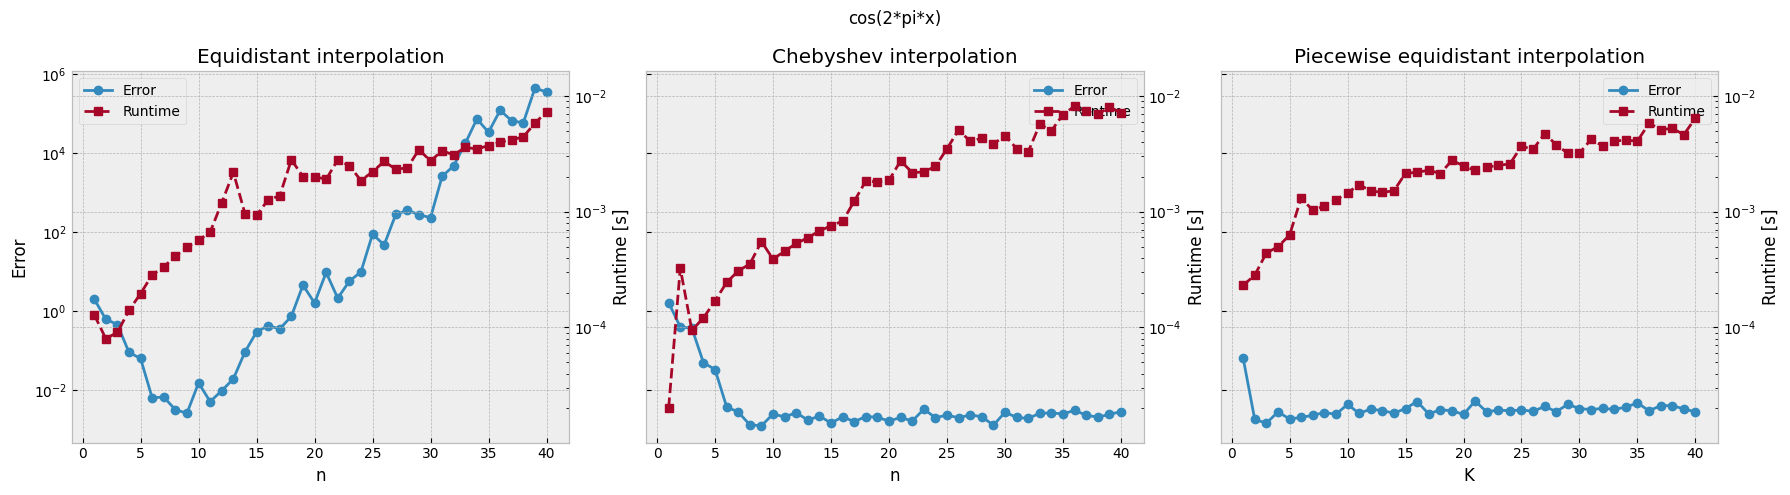

In [6]:
plot_time_interpolation(
    f_cos, 0, 1,
    n0=1, n_end=40,
    K0=1, K_end=40,
    noise = 0.001
)

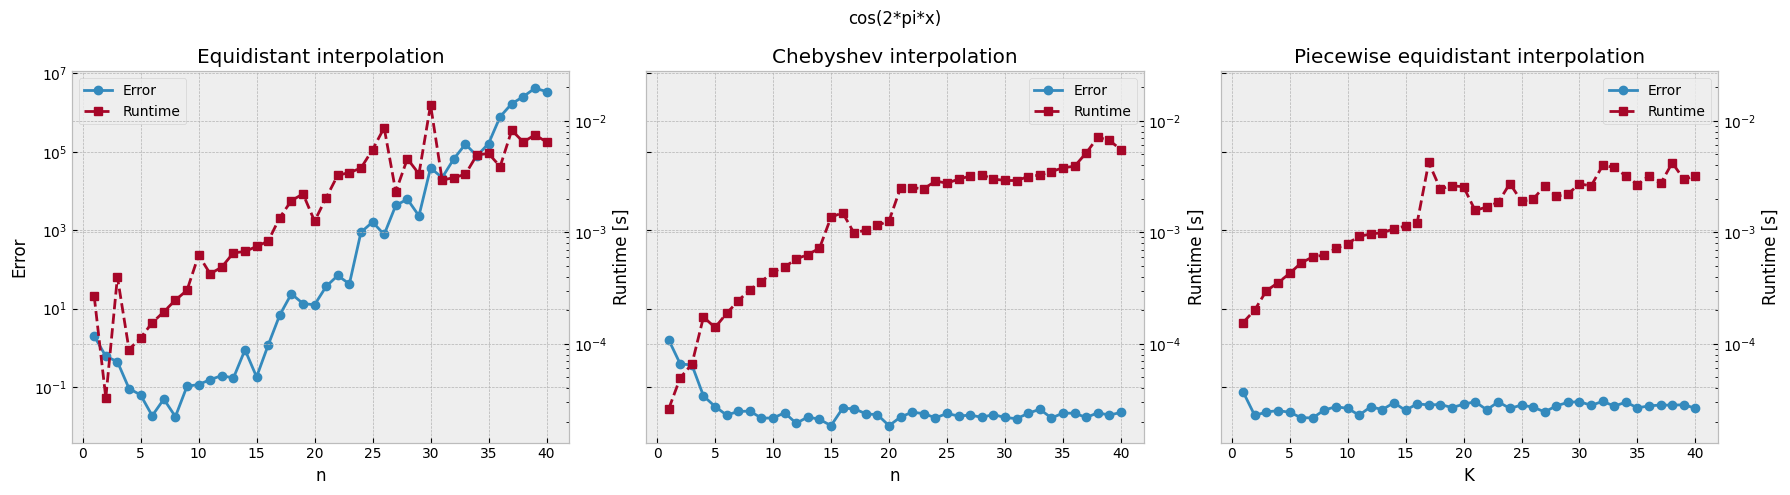

In [7]:
plot_time_interpolation(
    f_cos, 0, 1,
    n0=1, n_end=40,
    K0=1, K_end=40,
    noise = 0.01
)

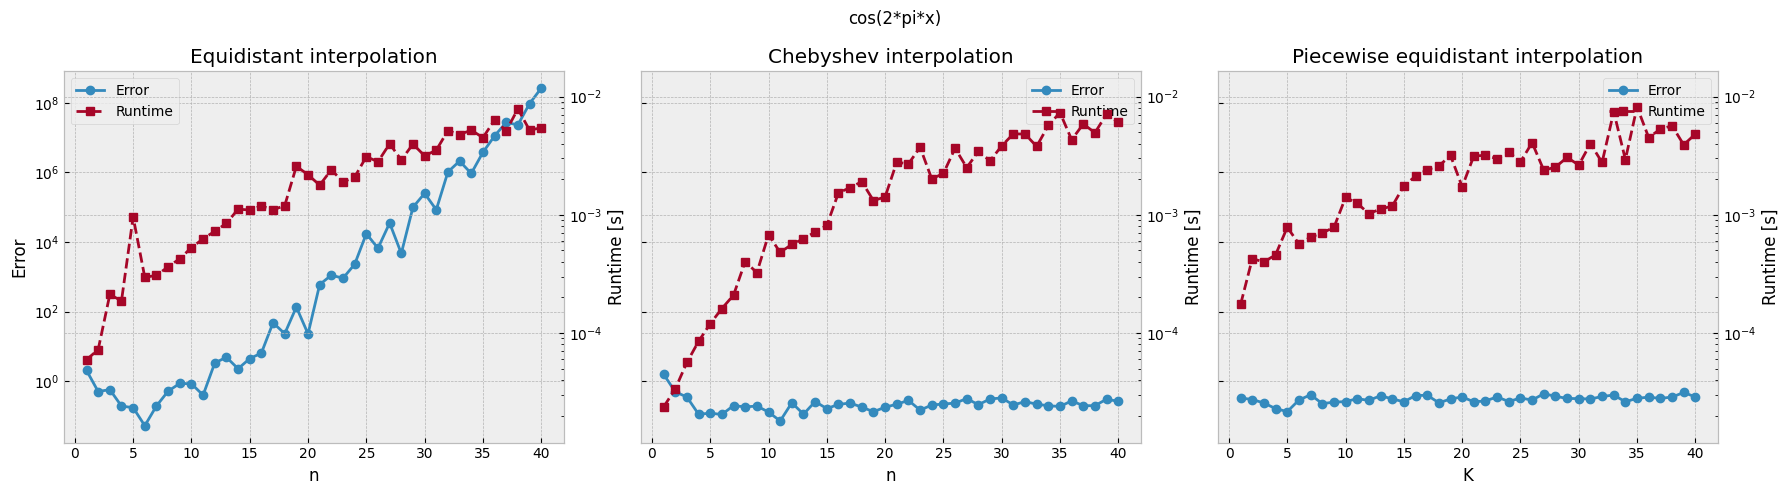

In [8]:
plot_time_interpolation(
    f_cos, 0, 1,
    n0=1, n_end=40,
    K0=1, K_end=40,
    noise = 0.1
)

To get a deeper insight into the stability of our methods we have done the interpolation again, but now added noise to the y-values we interpolate over. The noise is a percentage of the y-value. Above we have plotted max-error and runtime for all three methods but added $0.1\%$, $1\%$ and $10\%$ noise to the interpolated values. This is to simulate a real world situation where measurments are noisy.

Regular interpolation with has the same pattern as before. both node types give quick convergence, but `equidistant` nodes start diverging and `chebyshev` flatten out. Higher noise lifts the minimum error as one whould expect, so we do not get the same extreme precission. 

An important result of this higher minimum error is that piecewise interpolation reaches maximum precission almost immediatly. Since the noise makes hyper precise interpolation impossible, `Chebyshev` no longer has this advantage over piecewise. This in addition to the slower growing runtime suggests that piecewise is a better method for noisy-real world data.

## Conclusion:

In conclusion; piecewise interpolation has its advantages over regular interpolation. In cases where there are small sources of noise and we can pick our nodes as we please, regular interpolation with `Chebyshev` nodes is the clear winner. It has higher asymptotic runtime than piecewise, but since it can reach extreme precision in such few amount of nodes it does not really matter. 

This is rarely the case. Most sampling in the real world is done with equidistant nodes (e.g. stock markets, frequency analysis). And most real world cases suffer from noise and non-clean functions. In these cases the instability and larger runtimes of regular interpolation makes piecewise interpolation a better method due to its inherent stability and low comparably low runtimes. 